# WeatherPy

---

## Starter Code to Generate Random Geographic Coordinates and a List of Cities

In [42]:
# Dependencies and Setup
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import requests
import time
from scipy.stats import linregress

# Impor the OpenWeatherMap API key
from api_keys import weather_api_key

# Import citipy to determine the cities based on latitude and longitude
from citipy import citipy

### Generate the Cities List by Using the `citipy` Library

In [43]:
# Empty list for holding the latitude and longitude combinations
lat_lngs = []

# Empty list for holding the cities names
cities = []

# Range of latitudes and longitudes
lat_range = (-90, 90)
lng_range = (-180, 180)

# Create a set of random lat and lng combinations
lats = np.random.uniform(lat_range[0], lat_range[1], size=1500)
lngs = np.random.uniform(lng_range[0], lng_range[1], size=1500)
lat_lngs = zip(lats, lngs)

# Identify nearest city for each lat, lng combination
for lat_lng in lat_lngs:
    city = citipy.nearest_city(lat_lng[0], lat_lng[1]).city_name

    # If the city is unique, then add it to a our cities list
    if city not in cities:
        cities.append(city)

# Print the city count to confirm sufficient count
print(f"Number of cities in the list: {len(cities)}")

Number of cities in the list: 597


---

## Requirement 1: Create Plots to Showcase the Relationship Between Weather Variables and Latitude

### Use the OpenWeatherMap API to retrieve weather data from the cities list generated in the started code

In [44]:
# Set the API base URL
url = "http://api.openweathermap.org/data/2.5/weather"

# Define an empty list to fetch the weather data for each city
city_data = []

# Print to logger
print("Beginning Data Retrieval     ")
print("-----------------------------")

# Create counters
record_count = 1
set_count = 1

# Loop through all the cities in our list to fetch weather data
for i, city in enumerate(cities):

    # Group cities in sets of 50 for logging purposes
    if (i % 50 == 0 and i >= 50):
        set_count += 1
        record_count = 0

    # Create endpoint URL with each city
    city_url = f"{url}?q={city}&appid={weather_api_key}&units=metric"

    # Log the url, record, and set numbers
    print("Processing Record %s of Set %s | %s" % (record_count, set_count, city))

    # Add 1 to the record count
    record_count += 1

    # Run an API request for each of the cities
    try:
        # Make the actual API request
        response = requests.get(city_url)

        # Parse the JSON and retrieve data
        city_weather = response.json()

        # Parse out latitude, longitude, max temp, humidity, cloudiness, wind speed, country, and date
        city_lat = city_weather["coord"]["lat"]
        city_lng = city_weather["coord"]["lon"]
        city_max_temp = city_weather["main"]["temp_max"]
        city_humidity = city_weather["main"]["humidity"]
        city_clouds = city_weather["clouds"]["all"]
        city_wind = city_weather["wind"]["speed"]
        city_country = city_weather["sys"]["country"]
        city_date = city_weather["dt"]

        # Append the City information into city_data list
        city_data.append({"City": city,
                          "Lat": city_lat,
                          "Lng": city_lng,
                          "Max Temp": city_max_temp,
                          "Humidity": city_humidity,
                          "Cloudiness": city_clouds,
                          "Wind Speed": city_wind,
                          "Country": city_country,
                          "Date": city_date})

    # If an error is experienced, skip the city
    except:
        print("City not found. Skipping...")
        pass

    # pause to avoid rate limiting
    time.sleep(1)

# Indicate that Data Loading is complete
print("-----------------------------")
print("Data Retrieval Complete      ")
print("-----------------------------")

Beginning Data Retrieval     
-----------------------------
Processing Record 1 of Set 1 | hawaiian paradise park
Processing Record 2 of Set 1 | adamstown
Processing Record 3 of Set 1 | nova sintra
Processing Record 4 of Set 1 | laconia
Processing Record 5 of Set 1 | edinburgh of the seven seas
Processing Record 6 of Set 1 | ilulissat
Processing Record 7 of Set 1 | castillos
Processing Record 8 of Set 1 | adrian
Processing Record 9 of Set 1 | jamaame
Processing Record 10 of Set 1 | blackmans bay
Processing Record 11 of Set 1 | fale old settlement
Processing Record 12 of Set 1 | invercargill
Processing Record 13 of Set 1 | la ronge
Processing Record 14 of Set 1 | tadine
Processing Record 15 of Set 1 | grytviken
Processing Record 16 of Set 1 | northam
Processing Record 17 of Set 1 | coxim
Processing Record 18 of Set 1 | ushuaia
Processing Record 19 of Set 1 | la libertad
Processing Record 20 of Set 1 | quellon
Processing Record 21 of Set 1 | wamba
Processing Record 22 of Set 1 | vorgasho

In [45]:
# Convert the cities weather data into a Pandas DataFrame
city_data_df = pd.DataFrame(city_data)

# Show Record Count
city_data_df.count()

City          578
Lat           578
Lng           578
Max Temp      578
Humidity      578
Cloudiness    578
Wind Speed    578
Country       578
Date          578
dtype: int64

In [46]:
# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
0,hawaiian paradise park,19.5933,-154.9731,27.63,67,40,6.69,US,1746064307
1,adamstown,-25.0660,-130.1015,24.42,76,51,3.90,PN,1746064308
2,nova sintra,14.8667,-24.7167,21.33,82,4,11.44,CV,1746064309
3,laconia,43.5279,-71.4704,8.97,52,100,2.03,US,1746064310
4,edinburgh of the seven seas,-37.0676,-12.3116,17.66,93,100,14.72,SH,1746064312


In [47]:
# Export the City_Data into a csv
city_data_df.to_csv("output_data/cities.csv", index_label="City_ID")

In [48]:
# Read saved data
city_data_df = pd.read_csv("output_data/cities.csv", index_col="City_ID")

# Display sample data
city_data_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,hawaiian paradise park,19.5933,-154.9731,27.63,67,40,6.69,US,1746064307
1,adamstown,-25.0660,-130.1015,24.42,76,51,3.90,PN,1746064308
2,nova sintra,14.8667,-24.7167,21.33,82,4,11.44,CV,1746064309
3,laconia,43.5279,-71.4704,8.97,52,100,2.03,US,1746064310
4,edinburgh of the seven seas,-37.0676,-12.3116,17.66,93,100,14.72,SH,1746064312


### Create the Scatter Plots Requested

#### Latitude Vs. Temperature

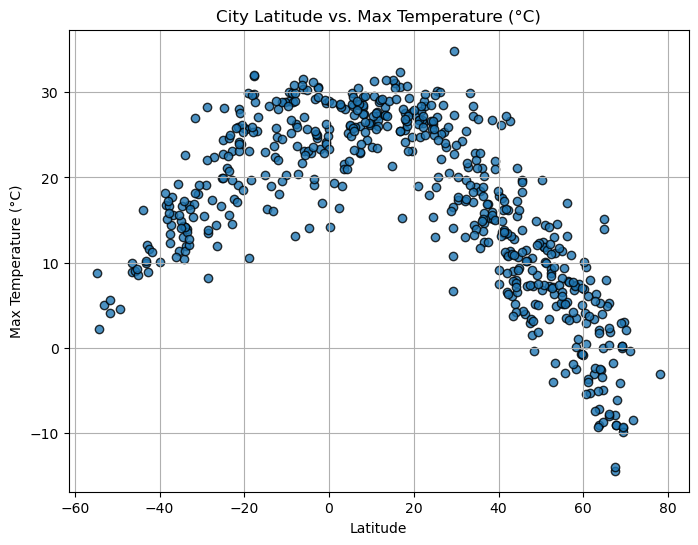

In [49]:
# Build scatter plot for latitude vs. temperature
plt.figure(figsize=(8,6))
plt.scatter(city_data_df["Lat"], city_data_df["Max Temp"], edgecolors="black", linewidths=1, alpha=0.8)


# Incorporate the other graph properties
plt.title("City Latitude vs. Max Temperature (°C)")
plt.xlabel("Latitude")
plt.ylabel("Max Temperature (°C)")
plt.grid(True)


# Save the figure
plt.savefig("output_data/Fig1.png")

# Show plot
plt.show()

#### Latitude Vs. Humidity

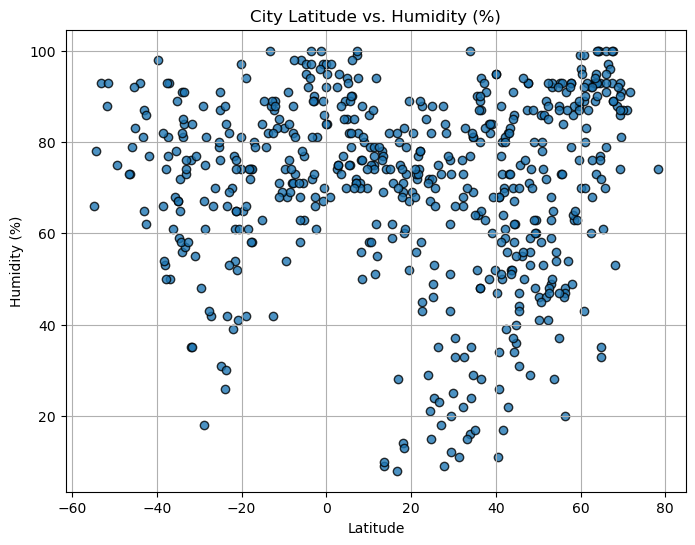

In [50]:
# Build the scatter plots for latitude vs. humidity
plt.figure(figsize=(8,6))
plt.scatter(city_data_df["Lat"], city_data_df["Humidity"], edgecolors="black", linewidths=1, alpha=0.8)

# Incorporate the other graph properties
plt.title("City Latitude vs. Humidity (%)")
plt.xlabel("Latitude")
plt.ylabel("Humidity (%)")
plt.grid(True)


# Save the figure
plt.savefig("output_data/Fig2.png")

# Show plot
plt.show()

#### Latitude Vs. Cloudiness

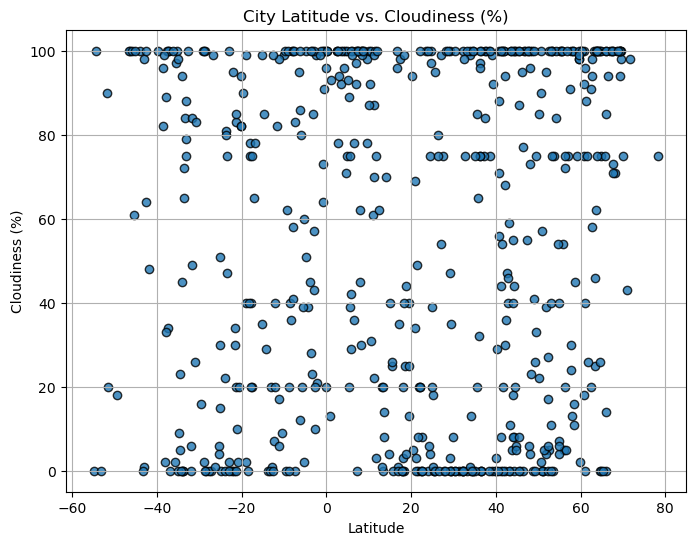

In [51]:
# Build the scatter plots for latitude vs. cloudiness
plt.figure(figsize=(8,6))
plt.scatter(city_data_df["Lat"], city_data_df["Cloudiness"], edgecolors="black", linewidths=1, alpha=0.8)


# Incorporate the other graph properties
plt.title("City Latitude vs. Cloudiness (%)")
plt.xlabel("Latitude")
plt.ylabel("Cloudiness (%)")
plt.grid(True)

# Save the figure
plt.savefig("output_data/Fig3.png")

# Show plot
plt.show()

#### Latitude vs. Wind Speed Plot

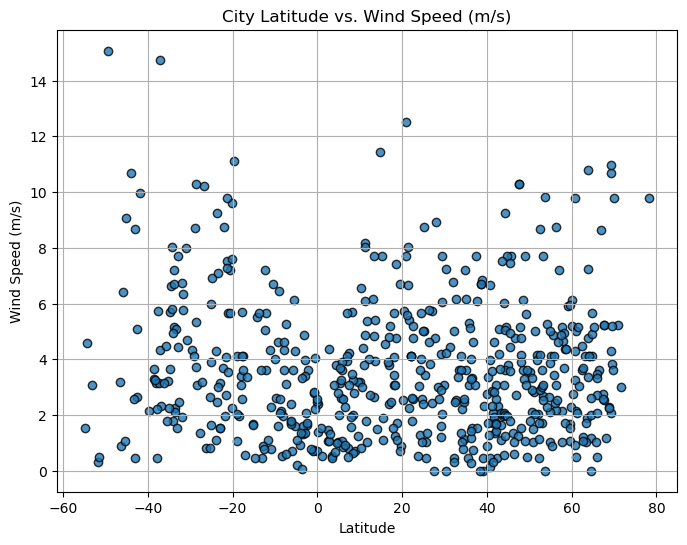

In [52]:
# Build the scatter plots for latitude vs. wind speed
plt.figure(figsize=(8,6))
plt.scatter(city_data_df["Lat"], city_data_df["Wind Speed"], edgecolors="black", linewidths=1, alpha=0.8)


# Incorporate the other graph properties
plt.title("City Latitude vs. Wind Speed (m/s)")
plt.xlabel("Latitude")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)


# Save the figure
plt.savefig("output_data/Fig4.png")

# Show plot
plt.show()

---

## Requirement 2: Compute Linear Regression for Each Relationship


In [53]:
# Define a function to create Linear Regression plots
def plot_linear_regression(x_values, y_values, title, xlabel, ylabel, text_coordinates, save_path):
    
    (slope, intercept, rvalue, pvalue, stderr) = linregress(x_values, y_values)
    regress_values = slope * x_values + intercept
    line_eq = f"y = {slope:.2f}x + {intercept:.2f}\nR² = {rvalue**2:.3f}"
    plt.figure(figsize=(8,6))
    plt.scatter(x_values, y_values, edgecolors="black", linewidths=1, alpha=0.8)
    plt.plot(x_values, regress_values, "r")
    plt.annotate(line_eq, text_coordinates, fontsize=12, color="red")
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.savefig(save_path)
    plt.show()


In [54]:
# Create a DataFrame with the Northern Hemisphere data (Latitude >= 0)
northern_hemi_df = city_data_df[city_data_df["Lat"] >= 0]

# Display sample data
northern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
0,hawaiian paradise park,19.5933,-154.9731,27.63,67,40,6.69,US,1746064307
2,nova sintra,14.8667,-24.7167,21.33,82,4,11.44,CV,1746064309
3,laconia,43.5279,-71.4704,8.97,52,100,2.03,US,1746064310
5,ilulissat,69.2167,-51.1000,0.01,74,100,2.06,GL,1746064313
7,adrian,41.8975,-84.0372,10.88,70,100,1.34,US,1746064027


In [55]:
# Create a DataFrame with the Southern Hemisphere data (Latitude < 0)
southern_hemi_df = city_data_df[city_data_df["Lat"] < 0]

# Display sample data
southern_hemi_df.head()

,City,Lat,Lng,Max Temp,Humidity,Cloudiness,Wind Speed,Country,Date
City_ID,,,,,,,,,
1,adamstown,-25.0660,-130.1015,24.42,76,51,3.90,PN,1746064308
4,edinburgh of the seven seas,-37.0676,-12.3116,17.66,93,100,14.72,SH,1746064312
6,castillos,-34.1667,-53.8333,10.45,91,45,1.77,UY,1746064315
9,blackmans bay,-43.0167,147.3167,12.07,65,1,0.45,AU,1746064318
10,fale old settlement,-9.3852,-171.2468,28.95,68,62,1.62,TK,1746064319


###  Temperature vs. Latitude Linear Regression Plot

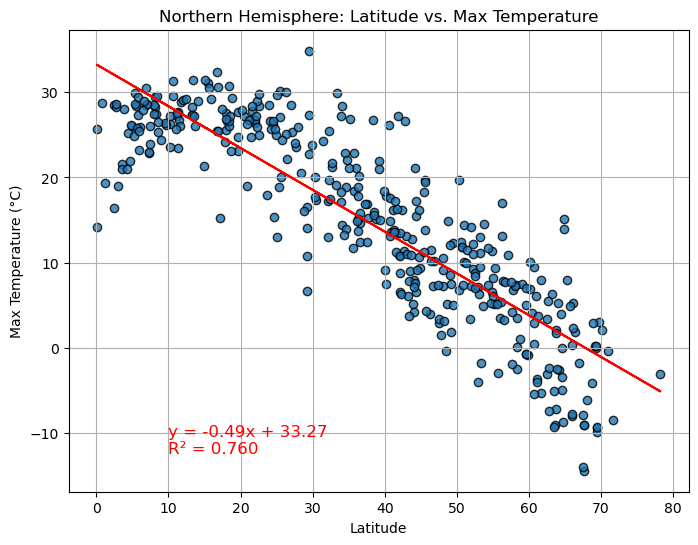

In [56]:
# Linear regression on Northern Hemisphere
plot_linear_regression(
    x_values=northern_hemi_df["Lat"],
    y_values=northern_hemi_df["Max Temp"],
    title="Northern Hemisphere: Latitude vs. Max Temperature",
    xlabel="Latitude",
    ylabel="Max Temperature (°C)",
    text_coordinates=(10, northern_hemi_df["Max Temp"].min() + 2),
    save_path="output_data/Fig5.png"
)

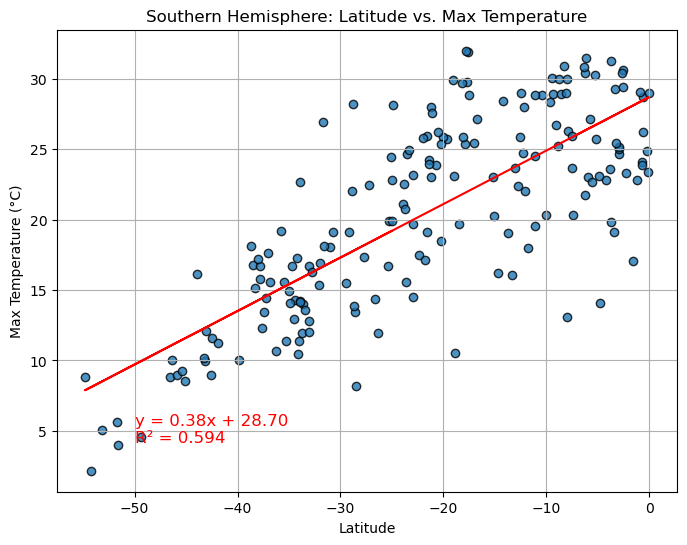

In [57]:
# Linear regression on Southern Hemisphere
plot_linear_regression(
    x_values=southern_hemi_df["Lat"],
    y_values=southern_hemi_df["Max Temp"],
    title="Southern Hemisphere: Latitude vs. Max Temperature",
    xlabel="Latitude",
    ylabel="Max Temperature (°C)",
    text_coordinates=(-50, southern_hemi_df["Max Temp"].min() + 2),
    save_path="output_data/Fig6.png"
)

**Discussion about the linear relationship:** There is a strong negative correlation between  latitude and maximum temperature of the Northern Hemisphere, but as you move farther from the equator (increasing latitude), the max temperature generally decreases. For the Southern Hemisphere, it is slightly weaker due to fewer populated land areas in the far southern latitudes. Both plots support the expected trend: cities closer to the equator tend to be warmer.

### Humidity vs. Latitude Linear Regression Plot

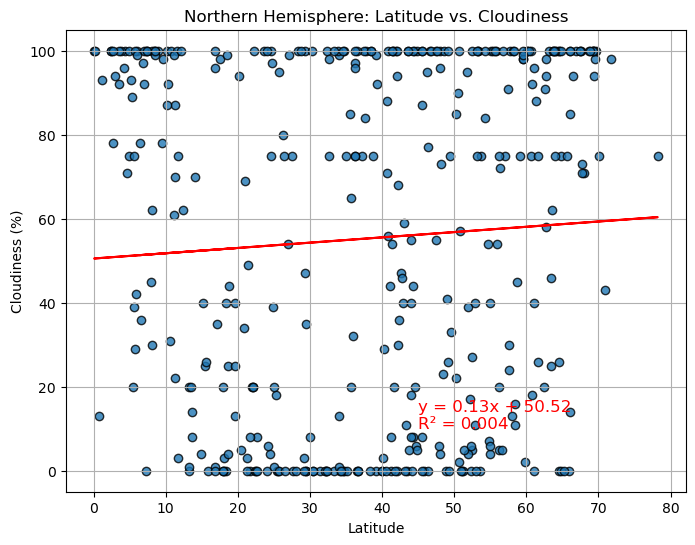

In [58]:
# Northern Hemisphere
plot_linear_regression(
    x_values=northern_hemi_df["Lat"],
    y_values=northern_hemi_df["Cloudiness"],
    title="Northern Hemisphere: Latitude vs. Cloudiness",
    xlabel="Latitude",
    ylabel="Cloudiness (%)",
    text_coordinates=(45, 10),
    save_path="output_data/Fig9.png"
)

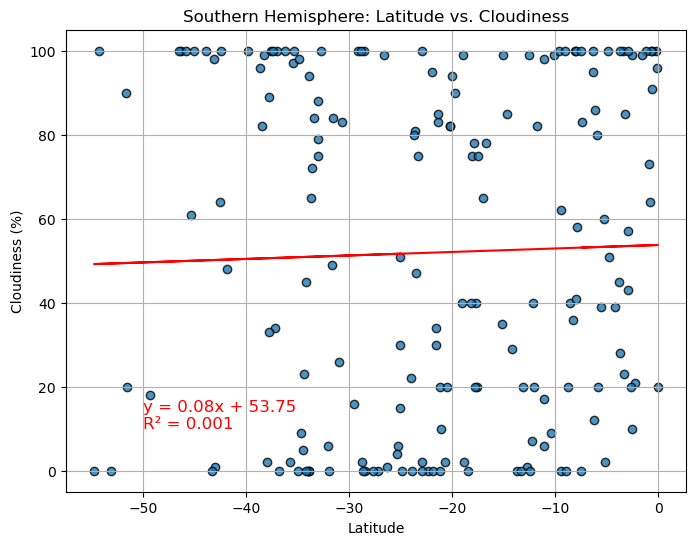

In [59]:
# Southern Hemisphere
plot_linear_regression(
    x_values=southern_hemi_df["Lat"],
    y_values=southern_hemi_df["Cloudiness"],
    title="Southern Hemisphere: Latitude vs. Cloudiness",
    xlabel="Latitude",
    ylabel="Cloudiness (%)",
    text_coordinates=(-50, 10),
    save_path="output_data/Fig10.png"
)

**Discussion about the linear relationship:** There is not a strong Linear relationship between the lat and cloudiness in both hemisphere. The cloudiness values are widely scattered across all latitudes, indicating that factors other than latitude (like local geography, weather patterns, and seasonality) play a greater role in determining cloud coverage.

### Cloudiness vs. Latitude Linear Regression Plot

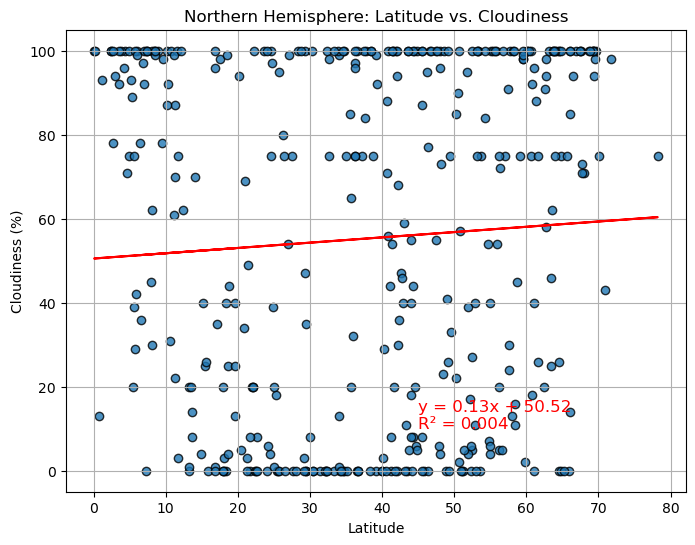

In [60]:
# Northern Hemisphere
plot_linear_regression(
    x_values=northern_hemi_df["Lat"],
    y_values=northern_hemi_df["Cloudiness"],
    title="Northern Hemisphere: Latitude vs. Cloudiness",
    xlabel="Latitude",
    ylabel="Cloudiness (%)",
    text_coordinates=(45, 10),
    save_path="output_data/Fig9.png"
)

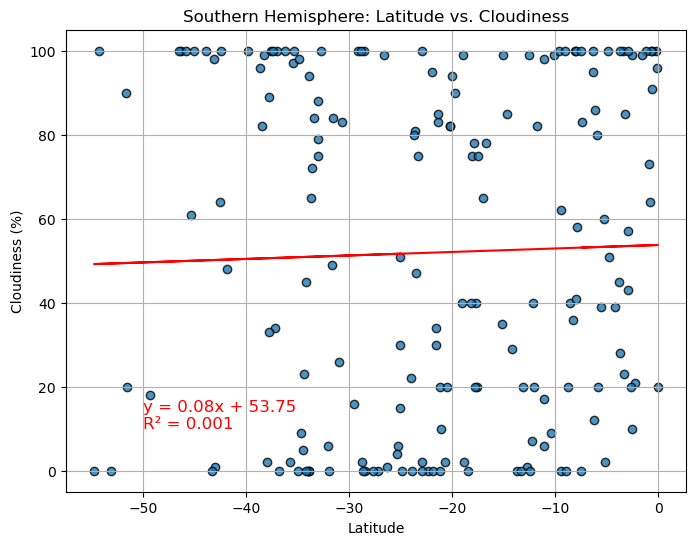

In [61]:
# Southern Hemisphere
plot_linear_regression(
    x_values=southern_hemi_df["Lat"],
    y_values=southern_hemi_df["Cloudiness"],
    title="Southern Hemisphere: Latitude vs. Cloudiness",
    xlabel="Latitude",
    ylabel="Cloudiness (%)",
    text_coordinates=(-50, 10),
    save_path="output_data/Fig10.png"
)

**Discussion about the linear relationship:** In both hemispheres, the scatter plots and regression lines show no clear linear trend between latitude and cloudiness. 

### Wind Speed vs. Latitude Linear Regression Plot

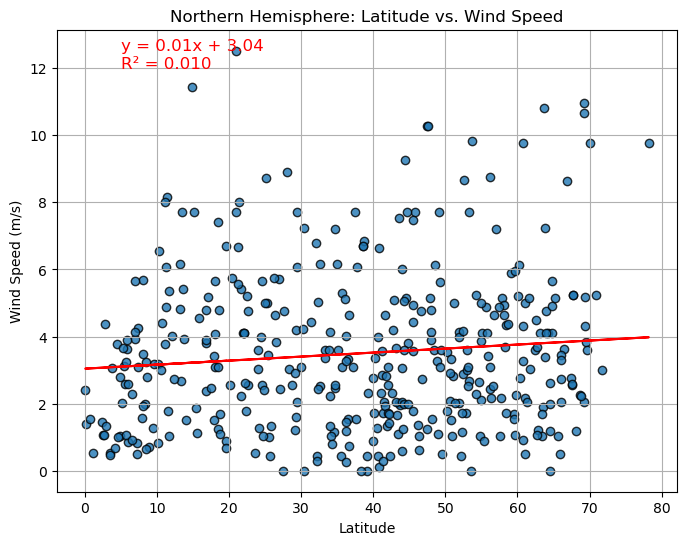

In [62]:
# Northern Hemisphere
plot_linear_regression(
    x_values=northern_hemi_df["Lat"],
    y_values=northern_hemi_df["Wind Speed"],
    title="Northern Hemisphere: Latitude vs. Wind Speed",
    xlabel="Latitude",
    ylabel="Wind Speed (m/s)",
    text_coordinates=(5, 12),
    save_path="output_data/Fig11.png"
)

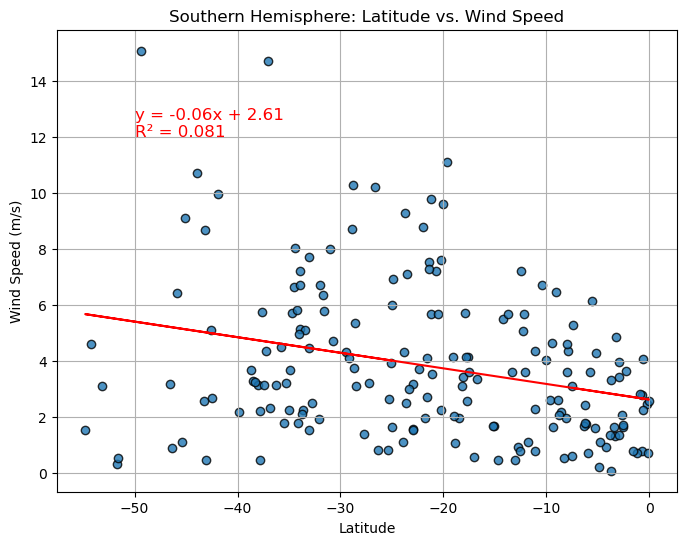

In [63]:
# Southern Hemisphere
plot_linear_regression(
    x_values=southern_hemi_df["Lat"],
    y_values=southern_hemi_df["Wind Speed"],
    title="Southern Hemisphere: Latitude vs. Wind Speed",
    xlabel="Latitude",
    ylabel="Wind Speed (m/s)",
    text_coordinates=(-50, 12),
    save_path="output_data/Fig12.png"
)


**Discussion about the linear relationship:** In both hemispheres, the linear regression plots for wind speed vs. latitude show very weak or no correlation. The data points are broadly scattered, and the regression lines appear relatively flat.